<a href="https://colab.research.google.com/github/VishalR787/Stock-price-predictor/blob/main/Stock_price_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install yfinance if not installed:
# pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# Fetch historical stock data (e.g., Apple)
ticker = "AAPL"
df = yf.download(ticker, start="2022-01-01", end="2023-01-01")

# Use only closing prices
df = df[['Close']]

/tmp/ipykernel_2228/3502938349.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2022-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
# Create features: Predict next day's close using past N days
N = 5
for i in range(1, N+1):
    df[f'Close_lag_{i}'] = df['Close'].shift(i)


In [4]:
# Drop missing values
df.dropna(inplace=True)

# Define features and target
X = df[[f'Close_lag_{i}' for i in range(1, N+1)]]
y = df['Close']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

In [5]:
# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error on Test Set: {mse:.2f}")

Mean Squared Error on Test Set: 13.28


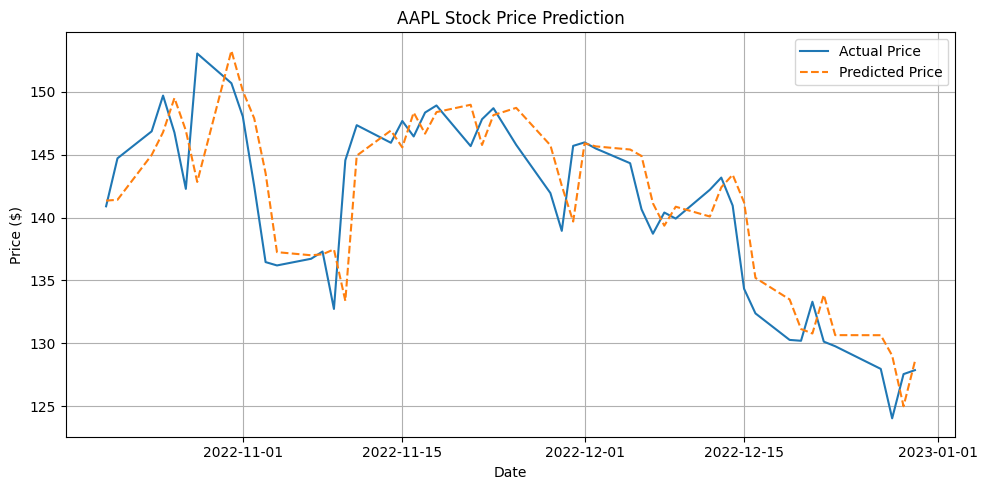

In [6]:
# Plot actual vs predicted prices
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test.values, label='Actual Price')
plt.plot(y_test.index, y_pred, label='Predicted Price', linestyle='--')
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()